<a href="https://colab.research.google.com/github/toche7/AI_ITM/blob/main/LabRegularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Adv2 : Regularization ใน Linear และ Logistic Regression

## บทนำสู่ Regularization

Regularization เป็นเทคนิคที่ใช้ใน Machine Learning เพื่อป้องกันการเกิด Overfitting โดยการเพิ่มเทอมค่าปรับ (penalty term) ให้กับฟังก์ชันความเสียหาย (loss function) ในระหว่างการฝึกโมเดล Overfitting เกิดขึ้นเมื่อโมเดลเรียนรู้ข้อมูลการฝึกมากเกินไป โดยจับเอาสัญญาณรบกวน (noise) และรูปแบบเฉพาะที่ไม่สามารถใช้ได้กับข้อมูลใหม่ที่โมเดลไม่เคยเห็น

ประเภทหลักของการ Regularization คือ L1 (Lasso) และ L2 (Ridge):

*   **L1 Regularization (Lasso)**: เพิ่มค่าปรับเท่ากับค่าสัมบูรณ์ของขนาดของสัมประสิทธิ์ (coefficients) ซึ่งอาจนำไปสู่โมเดลที่เบาบาง (sparse models) โดยที่สัมประสิทธิ์บางตัวมีค่าเป็นศูนย์อย่างแม่นยำ ซึ่งเป็นการเลือกคุณสมบัติ (feature selection) โดยปริยาย
*   **L2 Regularization (Ridge)**: เพิ่มค่าปรับเท่ากับกำลังสองของขนาดของสัมประสิทธิ์ ซึ่งจะทำให้สัมประสิทธิ์มีค่าเข้าใกล้ศูนย์แต่ไม่ค่อยมีค่าเป็นศูนย์อย่างแม่นยำ ช่วยลดผลกระทบและป้องกันน้ำหนัก (weights) ที่มีค่ามากเกินไป

ในห้องปฏิบัติการนี้ เราจะสำรวจแนวคิดเหล่านี้ในบริบทของทั้ง Linear Regression และ Logistic Regression

## 1. การตั้งค่าและการสร้างข้อมูลสำหรับ Linear Regression

ขั้นแรก เราจะนำเข้าไลบรารีที่จำเป็นและสร้างข้อมูลสังเคราะห์ (synthetic data) เราจะสร้างข้อมูลที่มีความสัมพันธ์เชิงเส้นตรงที่ทราบอยู่แล้ว แต่จะเพิ่มสัญญาณรบกวน (noise) และแนะนำคุณสมบัติที่ไม่เกี่ยวข้อง (irrelevant features) เพื่อจำลองสถานการณ์ที่สมจริงยิ่งขึ้นซึ่ง Regularization จะมีประโยชน์

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# For reproducibility
np.random.seed(42)

In [18]:
# Generate synthetic data
n_samples = 100
n_features = 10

X = np.random.rand(n_samples, n_features) * 10 # 10 features, 100 samples
y_true_coeffs = np.array([2.5, -1.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) # Only the first 3 are truly relevant
y = X @ y_true_coeffs + np.random.normal(0, 2, n_samples) # Add noise

# Add irrelevant features (noisy features) to make it more challenging
X_noisy = np.concatenate([X, np.random.rand(n_samples, 20) * 5], axis=1) # Add 20 more noisy features

# Create DataFrame for better visualization (optional)
df = pd.DataFrame(X_noisy, columns=[f'feature_{i+1}' for i in range(X_noisy.shape[1])])
df['target'] = y

print(f"Shape of X_noisy: {X_noisy.shape}")
print(f"Shape of y: {y.shape}")
display(df.head())

Shape of X_noisy: (100, 30)
Shape of y: (100,)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,target
0,7.344473,5.010206,6.043615,3.027736,2.003603,5.425702,4.402190,3.901132,6.725672,6.905066,...,1.343339,4.075916,1.795863,2.399782,4.828445,1.210861,3.606270,3.775589,1.104991,12.515556
1,0.459201,3.387445,4.117646,0.968922,2.359009,0.516418,9.962421,7.365572,0.874502,0.202494,...,2.040071,4.909040,1.897968,3.193127,0.805371,4.902244,3.519930,3.766888,0.328884,0.550522
2,7.192878,4.391922,7.867967,9.234760,5.993004,1.871084,7.821940,9.558117,5.802313,6.819974,...,0.382843,4.599507,2.652053,1.983710,2.675146,3.141466,4.609394,0.893465,1.477762,17.589752
3,3.374747,3.815277,7.346545,9.277711,6.289884,7.898479,1.716350,2.119591,5.320347,1.765542,...,0.407958,2.407945,2.030860,3.030887,2.194239,4.670384,2.673699,3.468630,4.482426,5.199632
4,6.349951,2.916532,7.915326,8.081103,4.637875,1.808106,6.467750,9.927870,6.225909,0.357747,...,1.592482,2.637630,4.733159,1.956141,0.324533,1.940807,0.728706,1.149948,3.090453,18.126765


## 2. การแบ่งข้อมูลและการปรับขนาด

ก่อนที่จะฝึกโมเดล เราจำเป็นต้องแบ่งข้อมูลออกเป็นชุดฝึก (training set) และชุดทดสอบ (testing set) เพื่อประเมินประสิทธิภาพของโมเดลกับข้อมูลที่ไม่เคยเห็น นอกจากนี้ การปรับขนาดคุณสมบัติ (feature scaling) ก็เป็นแนวปฏิบัติที่ดี โดยเฉพาะอย่างยิ่งสำหรับการ Regularization เพื่อให้แน่ใจว่าไม่มีคุณสมบัติใดที่มีอิทธิพลต่อเทอมค่าปรับ (penalty term) มากเกินไปเนื่องจากขนาดของมัน

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (70, 30)
X_test_scaled shape: (30, 30)


## 3. โมเดล Linear Regression (OLS, Ridge, Lasso)

ตอนนี้ เรามาฝึกและเปรียบเทียบโมเดล Linear Regression สามแบบกัน:

1.  **Ordinary Least Squares (OLS) Linear Regression**: โมเดลเชิงเส้นมาตรฐานที่ไม่มี Regularization
2.  **Ridge Regression (L2 Regularization)**: เพิ่มค่าปรับ L2 ให้กับฟังก์ชันความเสียหาย (loss function) ซึ่งจะลดขนาดของสัมประสิทธิ์เข้าใกล้ศูนย์
3.  **Lasso Regression (L1 Regularization)**: เพิ่มค่าปรับ L1 ให้กับฟังก์ชันความเสียหาย ซึ่งสามารถทำให้สัมประสิทธิ์บางตัวมีค่าเป็นศูนย์อย่างแม่นยำได้ ซึ่งเป็นการเลือกคุณสมบัติ (feature selection) โดยปริยาย

In [19]:
# 1. Ordinary Least Squares (OLS) Linear Regression
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)
ols_predictions = ols_model.predict(X_test_scaled)
ols_mse = mean_squared_error(y_test, ols_predictions)

print(f"OLS Mean Squared Error (MSE): {ols_mse:.2f}")

# 2. Ridge Regression (L2 Regularization)
# We use a chosen alpha (regularization strength); this value is typically tuned.
ridge_model = Ridge(alpha=1.0) # alpha=1.0 is default, but often needs tuning
ridge_model.fit(X_train_scaled, y_train)
ridge_predictions = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_predictions)

print(f"Ridge Mean Squared Error (MSE) (alpha=1.0): {ridge_mse:.2f}")

# 3. Lasso Regression (L1 Regularization)
# We use a chosen alpha. Lasso can be very sensitive to alpha, often requiring tuning.
lasso_model = Lasso(alpha=0.1) # A smaller alpha is often a good starting point for Lasso
lasso_model.fit(X_train_scaled, y_train)
lasso_predictions = lasso_model.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_predictions)

print(f"Lasso Mean Squared Error (MSE) (alpha=0.1): {lasso_mse:.2f}")

OLS Mean Squared Error (MSE): 6.30
Ridge Mean Squared Error (MSE) (alpha=1.0): 6.24
Lasso Mean Squared Error (MSE) (alpha=0.1): 3.84


## 4. การวิเคราะห์สัมประสิทธิ์และประสิทธิภาพ

มาตรวจสอบสัมประสิทธิ์ที่เรียนรู้โดยแต่ละโมเดลและเปรียบเทียบค่าความผิดพลาดกำลังสองเฉลี่ย (MSE) ของพวกเขาบนชุดทดสอบ เราคาดว่า Regularization จะลดขนาดของสัมประสิทธิ์ลง และ Lasso อาจทำให้บางตัวมีค่าเป็นศูนย์ โดยเฉพาะสำหรับคุณสมบัติที่ไม่เกี่ยวข้อง


--- Model Coefficients ---
True Coefficients (first 10 relevant features): [ 2.5 -1.   0.5  0.   0.   0.   0.   0.   0.   0. ]
OLS Coefficients (first 10): [ 7.58 -3.08  1.45 -0.06  0.44 -0.2  -0.05 -0.36 -0.02 -0.02]
Ridge Coefficients (first 10): [ 7.43 -3.01  1.41 -0.08  0.45 -0.2  -0.04 -0.38 -0.02 -0.03]
Lasso Coefficients (first 10): [ 7.39 -2.87  1.19 -0.    0.2  -0.   -0.   -0.26 -0.   -0.  ]

--- Model Performance (MSE on Test Set) ---
OLS MSE: 6.30
Ridge MSE: 6.24
Lasso MSE: 3.84


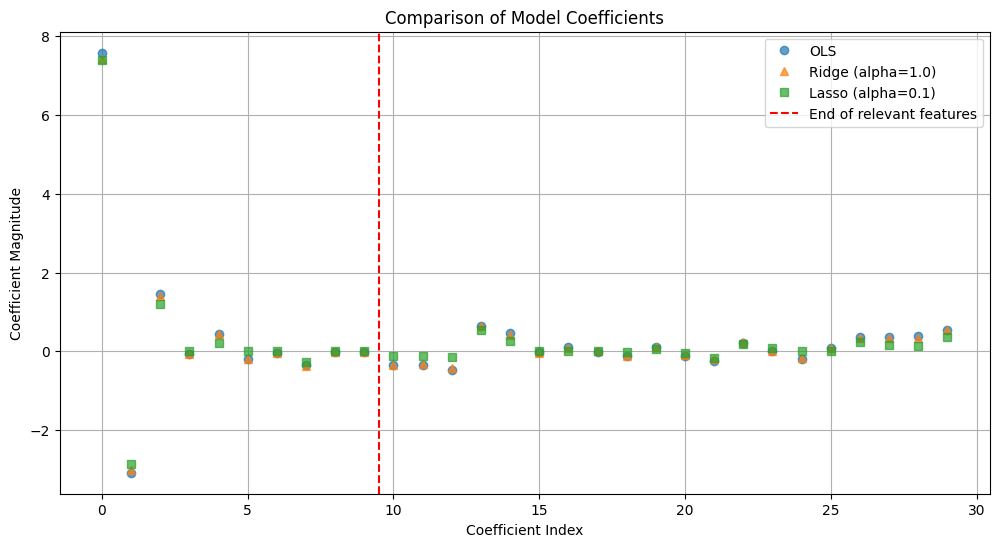

In [20]:
print("\n--- Model Coefficients ---")
print(f"True Coefficients (first 10 relevant features): {y_true_coeffs}")
print(f"OLS Coefficients (first 10): {ols_model.coef_[:10].round(2)}")
print(f"Ridge Coefficients (first 10): {ridge_model.coef_[:10].round(2)}")
print(f"Lasso Coefficients (first 10): {lasso_model.coef_[:10].round(2)}")

print("\n--- Model Performance (MSE on Test Set) ---")
print(f"OLS MSE: {ols_mse:.2f}")
print(f"Ridge MSE: {ridge_mse:.2f}")
print(f"Lasso MSE: {lasso_mse:.2f}")

# Let's visualize the magnitude of all coefficients for better understanding
plt.figure(figsize=(12, 6))
plt.plot(ols_model.coef_, 'o', label='OLS', alpha=0.7)
plt.plot(ridge_model.coef_, '^', label='Ridge (alpha=1.0)', alpha=0.7)
plt.plot(lasso_model.coef_, 's', label='Lasso (alpha=0.1)', alpha=0.7)
plt.axvline(x=n_features - 0.5, color='r', linestyle='--', label='End of relevant features')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Magnitude')
plt.title('Comparison of Model Coefficients')
plt.legend()
plt.grid(True)
plt.show()

### การตีความ:

*   **สัมประสิทธิ์ OLS**: คุณควรสังเกตว่า OLS กำหนดสัมประสิทธิ์ที่ไม่ใช่ศูนย์ให้กับคุณสมบัติที่ไม่เกี่ยวข้องหลายตัว (เกินดัชนี 9) ซึ่งอาจนำไปสู่ Overfitting
*   **สัมประสิทธิ์ Ridge**: Ridge Regression จะลดขนาดสัมประสิทธิ์ ทำให้มีขนาดเล็กลงแต่ไม่ค่อยมีค่าเป็นศูนย์อย่างแม่นยำ ซึ่งช่วยลดผลกระทบของคุณสมบัติที่มีความสำคัญน้อยกว่าโดยไม่ต้องลบออกทั้งหมด
*   **สัมประสิทธิ์ Lasso**: Lasso Regression ด้วยค่าปรับ L1 จะทำให้สัมประสิทธิ์ของคุณสมบัติที่ไม่เกี่ยวข้องหลายตัว (และบางครั้งคุณสมบัติที่เกี่ยวข้องที่มีความสำคัญน้อยกว่า) มีค่าเป็นศูนย์อย่างแม่นยำ ซึ่งเป็นการเลือกคุณสมบัติ (feature selection) โดยปริยาย สิ่งนี้สามารถทำให้โมเดลง่ายขึ้นและปรับปรุงความสามารถในการตีความได้
*   **การเปรียบเทียบ MSE**: เปรียบเทียบค่าความผิดพลาดกำลังสองเฉลี่ย (Mean Squared Error) บ่อยครั้งที่ Regularization สามารถนำไปสู่ข้อผิดพลาดในการฝึกที่สูงขึ้นเล็กน้อย แต่มีข้อผิดพลาดในการทดสอบที่ต่ำกว่า ซึ่งบ่งชี้ถึงการสรุปผลที่ดีขึ้นกับข้อมูลที่ไม่เคยเห็น

## 5. การตั้งค่าและการสร้างข้อมูลสำหรับ Logistic Regression

ตอนนี้ เรามาสำรวจ Regularization ในบริบทของ Logistic Regression ซึ่งใช้สำหรับงานการจัดประเภทแบบไบนารี (binary classification) เราจะสร้างชุดข้อมูลสังเคราะห์ใหม่สำหรับวัตถุประสงค์นี้ โดยที่ตัวแปรเป้าหมายเป็นแบบไบนารี

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Generate synthetic data for binary classification
n_samples_lr = 150
n_features_lr = 15 # Fewer features for Logistic Regression example

X_lr = np.random.randn(n_samples_lr, n_features_lr) # Features
y_true_coeffs_lr = np.array([3.0, -2.0, 1.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]) # First 3 are relevant

# Linear combination of features
linear_combination = X_lr @ y_true_coeffs_lr + np.random.normal(0, 1, n_samples_lr)

# Use sigmoid transformation to get probabilities and then binary labels
probabilities = 1 / (1 + np.exp(-linear_combination))
y_lr = (probabilities > 0.5).astype(int) # Binary labels

# Add some irrelevant features to X_lr
X_lr_noisy = np.concatenate([X_lr, np.random.randn(n_samples_lr, 10)], axis=1)

print(f"Shape of X_lr_noisy: {X_lr_noisy.shape}")
print(f"Shape of y_lr: {y_lr.shape}")
print(f"Target variable distribution: {np.bincount(y_lr)}")

Shape of X_lr_noisy: (150, 25)
Shape of y_lr: (150,)
Target variable distribution: [80 70]


## 6. การแบ่งข้อมูลและการปรับขนาดสำหรับ Logistic Regression

เช่นเดียวกับ Linear Regression เราจะแบ่งข้อมูล Logistic Regression ของเราออกเป็นชุดฝึกและชุดทดสอบ และปรับขนาดคุณสมบัติ การปรับขนาดมีความสำคัญอย่างยิ่งสำหรับโมเดล Logistic Regression แบบ Regularized เพื่อให้แน่ใจว่าการเปรียบเทียบเป็นธรรมและการ Regularization มีประสิทธิภาพ

In [7]:
# Split data into training and testing sets for logistic regression
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(X_lr_noisy, y_lr, test_size=0.3, random_state=42)

# Scale the features for logistic regression
scaler_lr = StandardScaler()
X_lr_train_scaled = scaler_lr.fit_transform(X_lr_train)
X_lr_test_scaled = scaler_lr.transform(X_lr_test)

print(f"X_lr_train_scaled shape: {X_lr_train_scaled.shape}")
print(f"X_lr_test_scaled shape: {X_lr_test_scaled.shape}")

X_lr_train_scaled shape: (105, 25)
X_lr_test_scaled shape: (45, 25)


## 7. โมเดล Logistic Regression (ไม่มี Regularization, L1, L2)

ตอนนี้ เรามาฝึกและเปรียบเทียบโมเดล Logistic Regression กัน:

1.  **Logistic Regression (ไม่มี Regularization)**: โมเดล Logistic Regression มาตรฐาน โปรดทราบว่า `LogisticRegression` ใน `sklearn` ใช้ Regularization แบบ L2 โดยค่าเริ่มต้น (`penalty='l2'`) ในการปิดใช้งาน Regularization เราจะตั้งค่า `penalty='none'` (หรือค่า `C` ที่สูงมาก โดย `C` คือค่าผกผันของความเข้ม Regularization)
2.  **Logistic Regression with L2 Regularization (เทียบเท่า Ridge)**: นี่คือค่าเริ่มต้นใน `sklearn.linear_model.LogisticRegression`
3.  **Logistic Regression with L1 Regularization (เทียบเท่า Lasso)**: ใช้ค่าปรับ L1 เพื่อส่งเสริมความเบาบางในสัมประสิทธิ์

In [22]:
# 1. Logistic Regression (No Regularization)
# C is the inverse of regularization strength. A large C means less regularization.
# To effectively disable regularization, we set C to a very high value.
logreg_no_reg = LogisticRegression(penalty='l2', C=1e9, solver='lbfgs', random_state=42) # Use a very high C to minimize regularization
logreg_no_reg.fit(X_lr_train_scaled, y_lr_train)
logreg_no_reg_predictions = logreg_no_reg.predict(X_lr_test_scaled)
logreg_no_reg_accuracy = accuracy_score(y_lr_test, logreg_no_reg_predictions)

print(f"Logistic Regression Accuracy (No Reg): {logreg_no_reg_accuracy:.2f}")

# 2. Logistic Regression with L2 Regularization
# C=1.0 is default but can be tuned. A lower C means stronger regularization.
logreg_l2 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42)
logreg_l2.fit(X_lr_train_scaled, y_lr_train)
logreg_l2_predictions = logreg_l2.predict(X_lr_test_scaled)
logreg_l2_accuracy = accuracy_score(y_lr_test, logreg_l2_predictions)

print(f"Logistic Regression Accuracy (L2, C=1.0): {logreg_l2_accuracy:.2f}")

# 3. Logistic Regression with L1 Regularization
# Use solver 'liblinear' or 'saga' for L1 penalty
logreg_l1 = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42) # C can be tuned
logreg_l1.fit(X_lr_train_scaled, y_lr_train)
logreg_l1_predictions = logreg_l1.predict(X_lr_test_scaled)
logreg_l1_accuracy = accuracy_score(y_lr_test, logreg_l1_predictions)

print(f"Logistic Regression Accuracy (L1, C=0.5): {logreg_l1_accuracy:.2f}")

Logistic Regression Accuracy (No Reg): 0.87
Logistic Regression Accuracy (L2, C=1.0): 0.87
Logistic Regression Accuracy (L1, C=0.5): 0.93


## 8. การวิเคราะห์สัมประสิทธิ์และประสิทธิภาพสำหรับ Logistic Regression

มาตรวจสอบสัมประสิทธิ์ที่เรียนรู้โดยแต่ละโมเดล Logistic Regression และเปรียบเทียบความแม่นยำของพวกเขาบนชุดทดสอบ เราคาดว่า L1 Regularization จะทำให้สัมประสิทธิ์บางตัวมีค่าเป็นศูนย์อีกครั้ง ซึ่งเป็นการเลือกคุณสมบัติ (feature selection) ในขณะที่ L2 Regularization จะลดขนาดของสัมประสิทธิ์ลง


--- Logistic Regression Model Coefficients (first 15 for original relevant features) ---
True Relevant Coefficients (first 3 are non-zero): [ 3.  -2.   1.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0. ]
No Regularization Coefficients: [ 37.58 -21.67  15.48   0.92  -2.58   4.73   0.8    2.85   1.4    3.29
  -0.16  -2.87   6.65   1.32   1.48]
L2 Regularization Coefficients (C=1.0): [ 2.96 -1.71  1.25  0.18  0.02  0.18  0.05  0.29  0.37  0.15  0.24 -0.32
  0.55  0.06 -0.15]
L1 Regularization Coefficients (C=0.5): [ 2.97 -1.79  1.22  0.08  0.    0.    0.    0.05  0.2   0.    0.   -0.08
  0.33  0.    0.  ]

--- Logistic Regression Model Performance (Accuracy on Test Set) ---
No Regularization Accuracy: 0.87
L2 Regularization Accuracy (C=1.0): 0.87
L1 Regularization Accuracy (C=0.5): 0.93


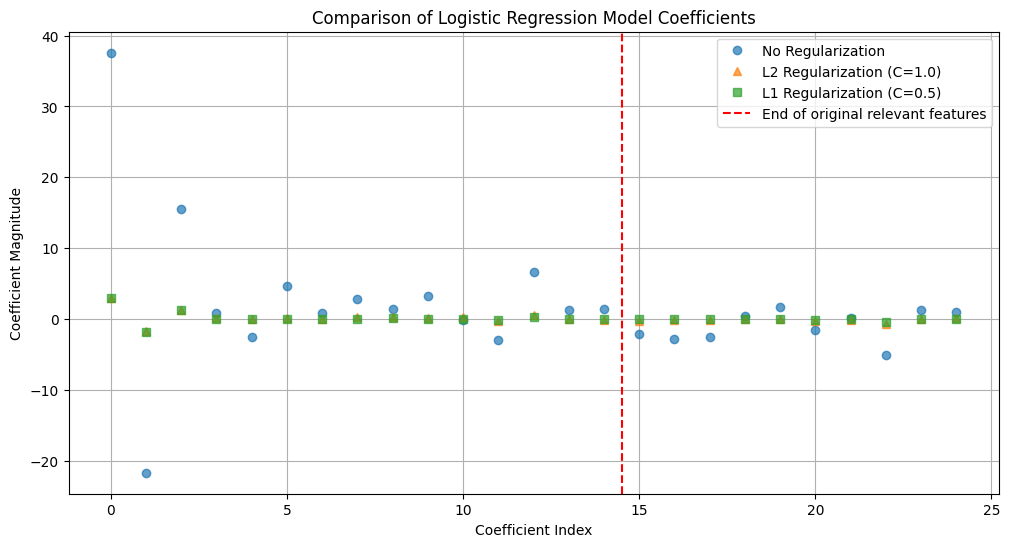

In [23]:
print("\n--- Logistic Regression Model Coefficients (first 15 for original relevant features) ---")
print(f"True Relevant Coefficients (first 3 are non-zero): {y_true_coeffs_lr[:15]}")
print(f"No Regularization Coefficients: {logreg_no_reg.coef_[0,:15].round(2)}")
print(f"L2 Regularization Coefficients (C=1.0): {logreg_l2.coef_[0,:15].round(2)}")
print(f"L1 Regularization Coefficients (C=0.5): {logreg_l1.coef_[0,:15].round(2)}")

print("\n--- Logistic Regression Model Performance (Accuracy on Test Set) ---")
print(f"No Regularization Accuracy: {logreg_no_reg_accuracy:.2f}")
print(f"L2 Regularization Accuracy (C=1.0): {logreg_l2_accuracy:.2f}")
print(f"L1 Regularization Accuracy (C=0.5): {logreg_l1_accuracy:.2f}")

# Visualize coefficients
plt.figure(figsize=(12, 6))
plt.plot(logreg_no_reg.coef_[0], 'o', label='No Regularization', alpha=0.7)
plt.plot(logreg_l2.coef_[0], '^', label='L2 Regularization (C=1.0)', alpha=0.7)
plt.plot(logreg_l1.coef_[0], 's', label='L1 Regularization (C=0.5)', alpha=0.7)
plt.axvline(x=n_features_lr - 0.5, color='r', linestyle='--', label='End of original relevant features')
plt.xlabel('Coefficient Index')
plt.ylabel('Coefficient Magnitude')
plt.title('Comparison of Logistic Regression Model Coefficients')
plt.legend()
plt.grid(True)
plt.show()

### การตีความ:

*   **ไม่มี Regularization**: คุณอาจเห็นว่าแม้จะไม่มี Regularization อย่างชัดเจน แต่ Logistic Regression ของ `sklearn` มักจะใช้ค่าปรับ L2 เริ่มต้นเล็กน้อย อย่างไรก็ตาม เมื่อตั้งค่า `penalty='none'` อย่างชัดเจน โมเดลจะพยายามใช้คุณสมบัติทั้งหมด
*   **Regularization แบบ L2**: คล้ายกับ Ridge Regression, Regularization แบบ L2 ใน Logistic Regression จะลดขนาดของสัมประสิทธิ์ลง ลดผลกระทบและช่วยป้องกัน Overfitting
*   **Regularization แบบ L1**: คล้ายกับ Lasso Regression, Regularization แบบ L1 ใน Logistic Regression จะทำการเลือกคุณสมบัติ (feature selection) โดยทำให้สัมประสิทธิ์ของคุณสมบัติที่มีความสำคัญน้อยกว่ามีค่าเป็นศูนย์อย่างแม่นยำ ซึ่งส่งผลให้โมเดลมีความเบาบางมากขึ้น ซึ่งสามารถตีความได้ง่ายขึ้นและบางครั้งมีความทนทานต่อสัญญาณรบกวนมากขึ้น
*   **การเปรียบเทียบความแม่นยำ**: สังเกตว่า Regularization ส่งผลต่อความแม่นยำในการทดสอบอย่างไร ความเข้มของ Regularization ที่ปรับจูนได้ดีสามารถปรับปรุงประสิทธิภาพการสรุปผลบนข้อมูลที่ไม่เคยเห็น แม้ว่าจะเพิ่มข้อผิดพลาดในการฝึกเล็กน้อยก็ตาม ค่า `C` ที่เหมาะสม (ค่าผกผันของความเข้ม Regularization) จำเป็นต้องค้นหาผ่านเทคนิคต่างๆ เช่น Cross-validation

## บทสรุป

ห้องปฏิบัติการนี้ได้สาธิตผลกระทบของ Regularization แบบ L1 (Lasso) และ L2 (Ridge) ทั้งในโมเดล Linear Regression และ Logistic Regression คุณควรสังเกตเห็นว่า:

*   **L2 Regularization** จะลดขนาดของสัมประสิทธิ์ ทำให้โมเดลมีความทนทานมากขึ้น
*   **L1 Regularization** จะทำการเลือกคุณสมบัติ (feature selection) โดยการตั้งค่าสัมประสิทธิ์บางตัวเป็นศูนย์ ซึ่งนำไปสู่โมเดลที่เบาบางและบ่อยครั้งที่ตีความได้ง่ายขึ้น
*   ทั้งสองเทคนิคมีเป้าหมายเพื่อป้องกัน **Overfitting** และปรับปรุงความสามารถในการ **สรุปผล** ของโมเดลบนข้อมูลที่ไม่เคยเห็น

การเลือกระหว่าง Regularization แบบ L1 และ L2 รวมถึงการปรับจูนพารามิเตอร์ความเข้มข้นของพวกมัน (เช่น `alpha` สำหรับ Ridge/Lasso, `C` สำหรับ Logistic Regression) เป็นสิ่งสำคัญสำหรับการสร้างโมเดล Machine Learning ที่มีประสิทธิภาพ